In [2]:
import os
import zarr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from pyproj import Transformer
import cartopy.feature as cfeature
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import pystac_client

# enable dask for lazy operations
dask_available = False
try:
    import dask.array as da
    import dask
    dask_available = True
except ImportError:
    pass


# Introduction

This notebook serves as a concise guide to working with **Zarr**, using
the Sentinel‑5P archive.  We'll cover:

- opening a Zarr store with `xarray`
- accessing and inspecting product groups
- efficient time slicing and variable extraction
- handling missing data, spatial aggregation, and plotting
- optional map visualisations

Practical snippets will help you migrate existing NetCDF workflows to
Zarr.


## Introduction to the Zarr data format

Zarr is an open-source format for the storage of chunked, compressed,
and N‑dimensional arrays.  It stores metadata in JSON and array data
in binary chunks which can live on local disk, network file systems, or
object stores.  Because the chunks are independent, Zarr supports
parallel reads/writes and incremental updates.


## Opening a Zarr store using xarray

We'll open the Sentinel‑5P archive.  The
`product_type` identifies a subgroup within the Zarr store.


In [2]:
product_type = "CO"
store_path = "/home/simon/eodc_datasync/private/eodc_logs/s5p/s5p.zarr"

ds = xr.open_zarr(store_path, group=product_type, consolidated=True,)#decode_cf=False)
ds

<xarray.Dataset> Size: 465MB
Dimensions:                                (time: 2690, y: 60, x: 90,
                                            spatial_ref: 1)
Coordinates:
  * time                                   (time) datetime64[ns] 22kB 2018-04...
  * y                                      (y) float64 480B 1.8e+06 ... 1.21e+06
  * x                                      (x) float64 720B 4.5e+06 ... 5.39e+06
  * spatial_ref                            (spatial_ref) int8 1B 0
Data variables:
    carbonmonoxide_total_column            (time, y, x) float64 116MB ...
    carbonmonoxide_total_column_corrected  (time, y, x) float64 116MB ...
    carbonmonoxide_total_column_precision  (time, y, x) float64 116MB ...
    qa_value                               (time, y, x) float64 116MB ...
Attributes: (12/36)
    Conventions:                       CF-1.7
    title:                             TROPOMI/S5P CO Column
    freq:                              1D
    platform:                          S5P
    sensor:                            TROPOMI
    spatial_resolution:                10000
    ...                                ...
    product_version:                   1.5.0
    processing_status:                 Nominal
    Status_MET_2D:                     Nominal
    Status_CTM_CO:                     Nominal
    Status_CTMCH4:                     Nominal
    crs_wkt:                           PROJCS["WGS84/Equi7Europe",GEOGCS["WGS...

### Accessing product groups within a Zarr archive

Zarr allows you to organise multiple products under one store; we
opened the `CO` group above, but you can list groups via `zarr.open`.


In [3]:
store = zarr.storage.LocalStore(store_path)
root = zarr.group(store=store)
print("subgroups:", list(root.group_keys()))

subgroups: ['AER_AI', 'CO', 'HCHO', 'NO2', 'SO2']


### Inspecting dataset structure

We can look at dimensions, variables and chunking information.

In [4]:
print(ds)
print("dims", ds.dims)
print("data vars", list(ds.data_vars))
print("chunks", ds.carbonmonoxide_total_column.chunks)


<xarray.Dataset> Size: 465MB
Dimensions:                                (time: 2690, y: 60, x: 90,
                                            spatial_ref: 1)
Coordinates:
  * time                                   (time) datetime64[ns] 22kB 2018-04...
  * y                                      (y) float64 480B 1.8e+06 ... 1.21e+06
  * x                                      (x) float64 720B 4.5e+06 ... 5.39e+06
  * spatial_ref                            (spatial_ref) int8 1B 0
Data variables:
    carbonmonoxide_total_column            (time, y, x) float64 116MB ...
    carbonmonoxide_total_column_corrected  (time, y, x) float64 116MB ...
    carbonmonoxide_total_column_precision  (time, y, x) float64 116MB ...
    qa_value                               (time, y, x) float64 116MB ...
Attributes: (12/36)
    Conventions:                       CF-1.7
    title:                             TROPOMI/S5P CO Column
    freq:                              1D
    platform:                        

## Efficient time slicing

Fetch a subset of the dataset by time without loading everything into
memory.


In [5]:
ds_time = ds.sel(time=slice("2024-01-01", "2024-12-31"))
print(ds_time)

<xarray.Dataset> Size: 63MB
Dimensions:                                (time: 366, y: 60, x: 90,
                                            spatial_ref: 1)
Coordinates:
  * time                                   (time) datetime64[ns] 3kB 2024-01-...
  * y                                      (y) float64 480B 1.8e+06 ... 1.21e+06
  * x                                      (x) float64 720B 4.5e+06 ... 5.39e+06
  * spatial_ref                            (spatial_ref) int8 1B 0
Data variables:
    carbonmonoxide_total_column            (time, y, x) float64 16MB ...
    carbonmonoxide_total_column_corrected  (time, y, x) float64 16MB ...
    carbonmonoxide_total_column_precision  (time, y, x) float64 16MB ...
    qa_value                               (time, y, x) float64 16MB ...
Attributes: (12/36)
    Conventions:                       CF-1.7
    title:                             TROPOMI/S5P CO Column
    freq:                              1D
    platform:                          S5P


## Extracting and working with specific variables

In [6]:
carbon = ds_time.carbonmonoxide_total_column
print(carbon)

<xarray.DataArray 'carbonmonoxide_total_column' (time: 366, y: 60, x: 90)> Size: 16MB
[1976400 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
  * y        (y) float64 480B 1.8e+06 1.79e+06 1.78e+06 ... 1.22e+06 1.21e+06
  * x        (x) float64 720B 4.5e+06 4.51e+06 4.52e+06 ... 5.38e+06 5.39e+06
Attributes:
    _ARRAY_DIMENSIONS:                                     ['time', 'y', 'x']
    grid_mapping:                                          spatial_ref
    units:                                                 mol m-2
    standard_name:                                         atmosphere_mole_co...
    long_name:                                             Vertically integra...
    ancillary_variables:                                   carbonmonoxide_tot...
    multiplication_factor_to_convert_to_molecules_percm2:  6.022140853952394e+19


## Handling Missing and Fill Values (Sanity Check)

By default, **xarray** automatically decodes CF-compliant metadata, including `_FillValue`, and converts declared missing values to `NaN`.  

Even so, performing a brief sanity check is good practice to confirm that the dataset has been decoded correctly and is ready for analysis.

In [ ]:
eodc_catalog = pystac_client.Client.open("https://dev.stac.eodc.eu/api/v1")
colllection_id = "SENTINEL5P_DAILY_AUT"
collection = eodc_catalog.get_collection(colllection_id)
collection

<CollectionClient id=SENTINEL5P_DAILY_AUT>

In [ ]:
asset = nodata = collection.to_dict()["assets"]["CO"]["raster:bands"][0]
nodata = asset["nodata"]
scale = asset["scale"]

print("nodat:", nodata)
print("scale:", scale)

nodat: 9.969209968386869e+36
scale: 1.0


In [ ]:
# Sanity check: verify missing values are NaN
carbon = ds.carbonmonoxide_total_column

# Only mask -9999 if it still exists (in case decode_cf did not handle it)
if float(carbon.min()) == nodata:
    carbon = carbon.where(carbon != nodata)


# How many NaNs are there?
n_missing = np.isnan(carbon).sum().item()
n_valid = np.sum(~np.isnan(carbon)).item()
print(f"Number of missing values (NaN): {n_missing}")
print(f"Number of valid values: {n_valid}")

# Optionally, check min/max to see if fill values were decoded
print("Min value:", float(carbon.min()))
print("Max value:", float(carbon.max()))

Number of missing values (NaN): 13348108
Number of valid values: 1177892
Min value: 0.0114
Max value: 0.08080000000000001


## Performing spatial aggregation

In [8]:
spatial_mean = carbon.mean(dim=("y","x"))
print(spatial_mean)

<xarray.DataArray 'carbonmonoxide_total_column' (time: 2690)> Size: 22kB
array([nan, nan, nan, ..., nan, nan, nan], shape=(2690,))
Coordinates:
  * time     (time) datetime64[ns] 22kB 2018-04-01 2018-04-02 ... 2025-08-11
Attributes:
    _ARRAY_DIMENSIONS:                                     ['time', 'y', 'x']
    grid_mapping:                                          spatial_ref
    units:                                                 mol m-2
    standard_name:                                         atmosphere_mole_co...
    long_name:                                             Vertically integra...
    ancillary_variables:                                   carbonmonoxide_tot...
    multiplication_factor_to_convert_to_molecules_percm2:  6.022140853952394e+19


## Creating temporal plots of aggregated data

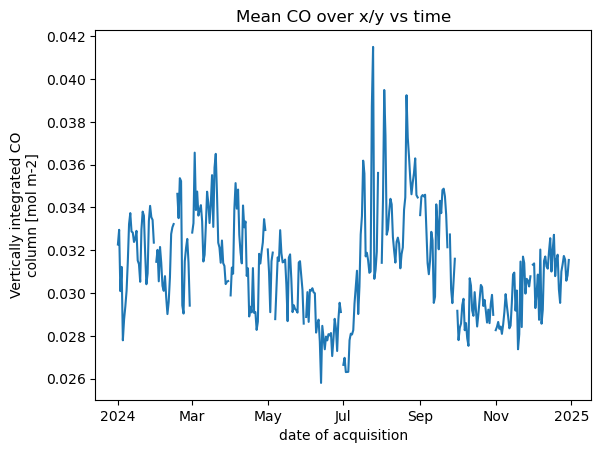

In [9]:
fig, ax = plt.subplots()
spatial_mean.plot(ax=ax)
ax.set_title("Mean CO over x/y vs time")
plt.show()


## Optional spatial visualization on a map


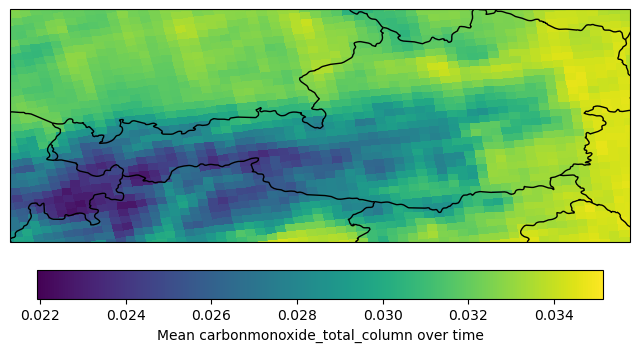

In [10]:
# Variable name to plot
var_name = "carbonmonoxide_total_column"

# Create a transformer to convert from the dataset CRS (EPSG:27704) to WGS84 (EPSG:4326)
# This is needed because Cartopy expects latitude/longitude coordinates
transformer = Transformer.from_crs("EPSG:27704", "EPSG:4326", always_xy=True)

# Create 2D meshgrid of the dataset coordinates
# X corresponds to the 'x' dimension and Y to the 'y' dimension
X, Y = np.meshgrid(carbon["x"].values, carbon["y"].values)

# Transform coordinates from projected CRS to latitude and longitude
lons, lats = transformer.transform(X, Y)

# Compute the mean over time to get a 2D array (spatial average)
mean_image = carbon.mean(dim="time").values  # 2D array: y * x

# Create a matplotlib figure with a Cartopy PlateCarree projection
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.PlateCarree()})

# Add map features: country borders, coastlines, and land background
ax.add_feature(cfeature.BORDERS, edgecolor='black')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Set the map extent to the area of interest (here: roughly Austria)
ax.set_extent([9, 17, 46, 49], crs=ccrs.PlateCarree())

# Plot the 2D data as a colored mesh on the map
im = ax.pcolormesh(
    lons, lats, mean_image,
    cmap='viridis',             # color map
    vmin=mean_image.min(),      # minimum value for color scale
    vmax=mean_image.max(),      # maximum value for color scale
    transform=ccrs.PlateCarree() # specify that data is in lat/lon
)

# Add a horizontal colorbar below the map to indicate values
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.046, pad=0.046)
cbar.set_label(f"Mean {var_name} over time")

# Display the figure
plt.show()

## Summary of advantages (compared with NetCDF)

- **Scalable chunked storage**: Data is physically stored in independent chunks,
  enabling efficient partial reads and processing of very large archives.

- **Efficient subsetting**: Selecting a time range or spatial subset only
  accesses the required chunks, which is especially beneficial for
  long time series and large multidimensional datasets.

- **Lazy evaluation with xarray/Dask**: Computation is deferred until
  explicitly triggered (e.g., via `.compute()` or `.values`), helping
  control memory usage for large datasets.

- **Improved parallelism**: Independent chunks allow concurrent reads
  and writes, making Zarr well suited for multi-core and distributed
  processing workflows.

- **Cloud-native design**: Zarr works naturally with object storage
  systems (S3, GCS, Azure Blob). No monolithic file access is required,
  which makes remote analysis more efficient.

- **Archive-oriented structure**: Multiple variables and groups can be
  stored within a single logical data store without rewriting an entire
  file, which simplifies managing evolving datasets.